---
title: Simulate neutron scattering in quantum materials with quantum circuits
description: Compute the dynamical structure factor of a quantum magnet using Trotter circuits and MPS simulation.
---

{/* cspell:ignore DSFs spinon Cloizeaux DMRG eigsh viridis fontsize vmax vmin Aer's cadetblue */}

# Simulate neutron scattering in quantum materials with quantum circuits

*Usage estimate: 13 minutes on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

## Learning outcomes

After completing this tutorial, you can expect to understand the following information:
- How inelastic neutron scattering (INS) spectra connect to dynamical structure factors (DSFs) of quantum spin models.
- How to prepare a ground state, apply a local perturbation, and perform Trotter time evolution on a quantum circuit.
- How to use approximate quantum compiling (AQC) with `qiskit-addon-aqc-tensor` to compress deep Trotter circuits for hardware execution.
- How to extract the retarded Green's function (RGF) from qubit expectation values and Fourier-transform it into a DSF.

## Prerequisites
It is recommended that you familiarize yourself with these topics:
- [Basics of Quantum Circuits and Gates](https://learning.quantum.ibm.com/course/basics-of-quantum-information)
- [Variational Algorithms and Hamiltonian Simulation](https://learning.quantum.ibm.com/course/variational-algorithm-design)
- [Introduction to Qiskit Primitives (Estimator & Sampler)](https://docs.quantum.ibm.com/guides/primitives)

## Background

In this tutorial, we reproduce the results of [Lee et al., arXiv:2603.15608](https://arxiv.org/abs/2603.15608) at a smaller scale. While that paper ran a 50-qubit experiment, here we run a 20-qubit experiment to keep the cost of performing approximate quantum compilation (AQC) more manageable.

### Inelastic neutron scattering and the dynamical structure factor

Inelastic neutron scattering (INS) is one of the most powerful experimental probes of magnetic excitations in quantum materials. When a beam of thermal or cold neutrons impinges on a crystal, individual neutrons exchange both momentum $\mathbf{q}$ and energy $\omega$ with the magnetic subsystem. The measured scattering intensity is proportional to the dynamical structure factor (DSF),

$$S^{\alpha\beta}(q,\omega) = \sum_{j} e^{-iq\,j}\int_{-\infty}^{\infty} dt\; e^{i\omega t}\, \langle S_0^{\alpha}(0)\, S_j^{\beta}(t)\rangle,$$

which encodes the full space-time correlations of the spin degrees of freedom.

### KCuF$_3$ — a canonical Luttinger-liquid magnet

Potassium copper fluoride (KCuF$_3$) is a quasi-one-dimensional antiferromagnet in which chains of spin-$\frac{1}{2}$ Cu$^{2+}$ ions interact via a nearest-neighbor Heisenberg exchange $J \approx 34\;\mathrm{meV}$, while the interchain coupling is only $\sim 2.7\%$ of $J$. At $T = 6\;\mathrm{K}$ where INS data are available, the spectrum is dominated by fractionalized spinon excitations characteristic of a Tomonaga-Luttinger liquid. Because the intrachain dynamics are well described by the one-dimensional spin-$\frac{1}{2}$ XXZ Hamiltonian at the isotropic point ($\epsilon = 1$),

$$H = J\sum_{i}\left[S_i^Z S_{i+1}^Z + \epsilon\left(S_i^X S_{i+1}^X + S_i^Y S_{i+1}^Y\right)\right],$$

KCuF$_3$ serves as an ideal benchmark for quantum simulation: the Hamiltonian is simple enough to implement on a quantum processor, yet the ground state is strongly entangled and the excitation spectrum features a broad two-spinon continuum.

### What we simulate and measure

The physical quantity we compute is the **retarded Green’s function** (RGF), defined as the time-dependent spin–spin correlation function

$$G^R_{\alpha\beta}(j, j_c, t) = -i\,\theta(t)\,\langle\psi_{\mathrm{GS}}|\,[S_j^\alpha(t),\, S_{j_c}^\beta(0)]\,|\psi_{\mathrm{GS}}\rangle,$$

where $j_c$ is a reference site (the chain center) and $S_j^\alpha(t) = e^{iHt}S_j^\alpha e^{-iHt}$ is the Heisenberg-picture spin operator. In this tutorial we focus on the $zz$ component ($\alpha = \beta = z$). On a quantum computer the RGF is accessed by preparing the ground state, applying a local perturbation at $j_c$, time-evolving the perturbed state, and measuring the single-qubit expectation value $\langle\sigma_j^z\rangle$ at every site $j$ for each time step. The key insight is that each $\langle\sigma_j^z\rangle$ gives the difference from the ground-state magnetization, which — for the antiferromagnetic ground state — directly yields $G^R(j, j_c, t)$.

By collecting $G^R(j, j_c, t)$ over all sites and time steps, we assemble a two-dimensional dataset that is then Fourier-transformed in both space and time to produce the **dynamical structure factor** $S(q,\omega)$. The DSF is the quantity directly measured in an INS experiment: it tells us what magnetic excitations exist at each momentum $q$ and energy $\omega$. For the isotropic Heisenberg chain the exact excitation spectrum is a **two-spinon continuum** — a broad band of scattering intensity bounded below by $\omega_{\mathrm{lower}}(q) = \frac{\pi}{2}|\sin q|$ (the des Cloizeaux–Pearson dispersion) and above by $\omega_{\mathrm{upper}}(q) = \pi|\sin(q/2)|$. Reproducing this continuum from a quantum circuit serves as a stringent end-to-end benchmark: it validates the ground-state preparation, perturbation, Trotter time evolution, and measurement protocol all at once.

### Quantum-simulation workflow

The workflow mirrors the physics of an INS event. We (1) prepare the many-body ground state $|\psi_{\mathrm{GS}}\rangle$ on $n$ qubits, (2) apply a local spin-flip perturbation $U_{j_c} = \frac{1}{\sqrt{2}}(I - i\sigma^z_{j_c})$ at the chain center to mimic the neutron’s spin transfer, (3) evolve under $H$ for discrete time steps using second-order Trotterization, and (4) measure $\langle\sigma_i^z\rangle$ on every qubit at each step to obtain the RGF. A two-dimensional discrete Fourier transform then yields the DSF $S(q,\omega)$.

The observable we measure at every time step is $\sigma_i^z$ on each qubit $i$. In Qiskit this is represented as a list of `SparsePauliOp` operators — one single-qubit $Z$ embedded in the $n$-qubit identity string for each site. These observables are constructed once during the problem-mapping step (Step 1) and reused for every circuit.

### Approximate quantum compiling (AQC)

Deep Trotter circuits can be compressed with **approximate quantum compiling (AQC)**, which replaces the first several Trotter layers with a shorter parameterized ansatz whose parameters are classically optimized to maximize the MPS-level fidelity with the original deep circuit. The remaining Trotter steps are appended exactly, producing a "mixed" AQC + Trotter circuit with substantially fewer two-qubit gates. In this tutorial AQC is demonstrated conceptually in Step 2 and applied programmatically in the large-scale section.

### MPS simulation

For a one-dimensional system, matrix-product-state (MPS) methods can efficiently simulate both ground-state preparation (via DMRG) and circuit-level time evolution. By controlling the bond dimension $\chi$, one trades off accuracy against computational cost. In this tutorial we use MPS simulation within `qiskit-addon-aqc-tensor` to compute high-fidelity AQC ansätze that compress the deep Trotter circuits for hardware execution.

## Requirements
Before starting this tutorial, be sure you have the following installed:

- Qiskit SDK with visualization extras (`pip install qiskit[visualization]`)
- Qiskit Runtime (`pip install qiskit-ibm-runtime`)
- qiskit-addon-aqc-tensor with quimb and JAX extras (`pip install 'qiskit-addon-aqc-tensor[quimb-jax]'`)

## Setup

In [1]:
import timeit
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import quimb as qu
import quimb.tensor as qtn
import scipy.optimize
import scipy.sparse.linalg
from numpy.typing import NDArray
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_addon_aqc_tensor import generate_ansatz_from_circuit
from qiskit_addon_aqc_tensor.objective import MaximizeStateFidelity
from qiskit_addon_aqc_tensor.simulation import tensornetwork_from_circuit
from qiskit_addon_aqc_tensor.simulation.quimb import QuimbSimulator

# ════════════════════════════════════════════════════════════
#  Hamiltonian construction (exact diagonalization)
# ════════════════════════════════════════════════════════════


def build_xxz_hamiltonian(
    n: int, J: float = 1.0, Jz: float = 1.0
) -> SparsePauliOp:
    """Build the 1D XXZ Hamiltonian as a SparsePauliOp (open boundary).

    H = J * sum_i [ Jz * Sz_i Sz_{i+1}
                     + 0.5*(S+_i S-_{i+1} + S-_i S+_{i+1}) ]
      = J/4 * sum_{nn pair} [ Jz * ZZ + (XX + YY) ]

    Args:
        n: Number of qubits (sites).
        J: XY coupling strength.
        Jz: Ising coupling strength.

    Returns:
        The XXZ Hamiltonian as a SparsePauliOp.
    """
    terms = []
    for i in range(n - 1):
        terms.append(("ZZ", [i, i + 1], 0.25 * J * Jz))
        terms.append(("XX", [i, i + 1], 0.25 * J))
        terms.append(("YY", [i, i + 1], 0.25 * J))
    return SparsePauliOp.from_sparse_list(terms, num_qubits=n)


# ════════════════════════════════════════════════════════════
#  Trotter circuit builder (2nd-order Suzuki-Trotter)
# ════════════════════════════════════════════════════════════


def trotter_circuit(
    n: int,
    gs_circuit: QuantumCircuit,
    time_steps: int,
    half_t: QuantumCircuit,
    full_t: QuantumCircuit,
    site: int,
) -> QuantumCircuit:
    """Build a 2nd-order Trotter circuit for time evolution.

    Args:
        n: Number of qubits.
        gs_circuit: Ground-state preparation circuit.
        time_steps: Number of Trotter steps.
        half_t: Half-time-step 2-qubit gate.
        full_t: Full-time-step 2-qubit gate.
        site: Perturbation site (center qubit).

    Returns:
        The full Trotter circuit with perturbation applied at ``site``.
    """
    qc = gs_circuit.copy()
    qc.rz(np.pi / 2, site)  # perturbation
    for i in range(n // 2):  # half even layer
        qc.compose(half_t, [2 * i, 2 * i + 1], inplace=True)
    for i in range(n // 2 - 1):  # full odd layer
        qc.compose(full_t, [2 * i + 1, 2 * i + 2], inplace=True)
    for _ in range(time_steps - 1):  # interior steps
        for i in range(n // 2):
            qc.compose(full_t, [2 * i, 2 * i + 1], inplace=True)
        for i in range(n // 2 - 1):
            qc.compose(full_t, [2 * i + 1, 2 * i + 2], inplace=True)
    for i in range(n // 2):  # half even layer
        qc.compose(half_t, [2 * i, 2 * i + 1], inplace=True)
    return qc


# ════════════════════════════════════════════════════════════
#  Mixed (AQC + Trotter) circuit
# ════════════════════════════════════════════════════════════


def mixed_circuit(
    n: int,
    aqc_circuit: QuantumCircuit,
    time_diff: int,
    half_t: QuantumCircuit,
    full_t: QuantumCircuit,
) -> QuantumCircuit:
    """Concatenate additional Trotter steps onto an AQC-compressed circuit.

    Args:
        n: Number of qubits.
        aqc_circuit: AQC-optimized circuit covering the first few steps.
        time_diff: Number of additional Trotter steps to append.
        half_t: Half-time-step 2-qubit gate.
        full_t: Full-time-step 2-qubit gate.

    Returns:
        The mixed AQC + Trotter circuit.
    """
    qc = aqc_circuit.copy()
    if time_diff != 0:
        for i in range(n // 2):
            qc.compose(half_t, [2 * i, 2 * i + 1], inplace=True)
        for i in range(n // 2 - 1):
            qc.compose(full_t, [2 * i + 1, 2 * i + 2], inplace=True)
        for _ in range(time_diff - 1):
            for i in range(n // 2):
                qc.compose(full_t, [2 * i, 2 * i + 1], inplace=True)
            for i in range(n // 2 - 1):
                qc.compose(full_t, [2 * i + 1, 2 * i + 2], inplace=True)
        for i in range(n // 2):
            qc.compose(half_t, [2 * i, 2 * i + 1], inplace=True)
    return qc


# ════════════════════════════════════════════════════════════
#  DSF via discrete Fourier transform
# ════════════════════════════════════════════════════════════


def get_dsf(
    n: int,
    rgf_mat: NDArray[np.floating],
    dt: float,
    time_steps: int,
    q_steps: int,
    w_steps: int,
) -> NDArray[np.floating]:
    """Compute the dynamical structure factor from the retarded Green's function.

    Uses the center-site approximation and a discrete Fourier transform.

    Args:
        n: Number of qubits (sites).
        rgf_mat: RGF matrix of shape ``(time_steps, n)``.
        dt: Trotter time-step size.
        time_steps: Number of time steps.
        q_steps: Number of momentum points.
        w_steps: Number of frequency points.

    Returns:
        DSF array of shape ``(w_steps, q_steps)``.
    """
    green = rgf_mat / 4  # sigma -> S=1/2
    omega_max = np.pi / dt
    q_points = np.arange(0, 2 * np.pi, 2 * np.pi / q_steps)
    omegas = np.arange(0, omega_max, omega_max / w_steps)
    green_map = np.zeros((omegas.shape[0], q_points.shape[0]))
    center = n // 2 - 1
    for iw, w in enumerate(omegas):
        exponent = np.exp(1j * w * dt * np.arange(1, time_steps + 1))
        S_w = np.dot(green.T, exponent) * dt
        for iq, q in enumerate(q_points):
            q_matrix = np.exp(-1j * q * np.arange(-center, center + 2, 1))
            green_map[iw, iq] = np.imag(np.dot(S_w, q_matrix))
    return green_map


# ════════════════════════════════════════════════════════════
#  Plotting helpers
# ════════════════════════════════════════════════════════════


def plot_dsf(
    dsf: NDArray[np.floating],
    dt: float,
    q_steps: int,
    w_steps: int,
    title: str | None = None,
) -> None:
    """Heat-map of the dynamical structure factor.

    Args:
        dsf: DSF array of shape ``(w_steps, q_steps)``.
        dt: Trotter time-step size.
        q_steps: Number of momentum points.
        w_steps: Number of frequency points.
        title: Optional plot title.
    """
    omega_max = np.pi / dt
    q_points = np.arange(0, 2 * np.pi, 2 * np.pi / q_steps)
    omegas = np.arange(0, omega_max, omega_max / w_steps)
    x, y = np.meshgrid(q_points, omegas)
    fig, ax = plt.subplots(figsize=(8, 5))
    c = ax.pcolormesh(x, y, dsf / np.max(dsf), cmap="viridis", shading="auto")
    fig.colorbar(c, ax=ax, label="Normalized intensity")
    ax.set_ylim(0, 3.6)
    ax.set_xlim(0, 2 * np.pi - 2 * np.pi / q_steps)
    ax.set_xlabel(r"$q$", fontsize=16)
    ax.set_ylabel(r"$\tilde{\omega} = \omega / J$", fontsize=16)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    if title:
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_rgf(
    n: int,
    rgf_mat: NDArray[np.floating],
    time_steps: int,
    dt: float,
    title: str | None = None,
) -> None:
    """Heat-map of the retarded Green's function in real space and time.

    Args:
        n: Number of qubits (sites).
        rgf_mat: RGF matrix of shape ``(time_steps, n)``.
        time_steps: Number of time steps.
        dt: Trotter time-step size.
        title: Optional plot title.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    qubit_axis = np.arange(n)
    t_axis = np.arange(1, time_steps + 1) * dt
    x, y = np.meshgrid(qubit_axis, t_axis)
    c = ax.pcolormesh(
        x,
        y,
        np.real(rgf_mat),
        cmap="RdBu",
        vmax=0.5,
        vmin=-0.5,
        shading="auto",
    )
    fig.colorbar(c, ax=ax, label=r"Re $G^R(j, j_c, t)$")
    ax.set_xlabel("Qubit", fontsize=16)
    ax.set_ylabel(r"Time", fontsize=16)
    if title:
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# ════════════════════════════════════════════════════════════
#  Variational ground-state ansatz (HVA)
# ════════════════════════════════════════════════════════════


def build_gs_ansatz(
    n: int, params: NDArray[np.floating], layers: int
) -> QuantumCircuit:
    """Build the Hamiltonian variational ansatz (HVA) circuit for
    ground-state preparation of the 1D Heisenberg model.

    Starts from a product of singlet pairs and applies alternating
    odd/even layers of parameterized XXZ pair-evolution gates.

    Args:
        n: Number of qubits (must be even).
        params: Variational parameters, length ``2 * layers``.
        layers: Number of HVA layers.

    Returns:
        The HVA preparation circuit.
    """
    qc = QuantumCircuit(n)
    # Initial singlet product state
    for i in range(n // 2):
        qc.x(2 * i)
        qc.x(2 * i + 1)
        qc.h(2 * i + 1)
        qc.cx(2 * i + 1, 2 * i)
    # Variational layers: each pair gate is exp(-i theta (XX+YY+ZZ)/2)
    H_pair_hva = SparsePauliOp(["XX", "YY", "ZZ"], coeffs=[0.5, 0.5, 0.5])
    for r in range(layers):
        for i in range(1, (n + 1) // 2):  # odd layer
            qc.append(
                PauliEvolutionGate(H_pair_hva, time=params[2 * r]),
                [2 * i - 1, 2 * i],
            )
        for i in range(n // 2):  # even layer
            qc.append(
                PauliEvolutionGate(H_pair_hva, time=params[2 * r + 1]),
                [2 * i, 2 * i + 1],
            )
    return qc


def optimize_gs_params(
    n: int,
    layers: int,
    x0: NDArray[np.floating],
    J: float = 1.0,
    Jz: float = 1.0,
    *,
    max_bond: int = None,
    cutoff: float = 1e-10,
    method: str = "COBYQA",
    options: dict | None = None,
) -> tuple[NDArray[np.floating], float]:
    """Optimize HVA parameters by minimizing ``<H>`` via quimb ``CircuitMPS``.

    The HVA circuit is simulated as a matrix product state with the given
    bond-dimension truncation, and ``<H>`` is evaluated as a sum of
    nearest-neighbor pair terms ``J/4 * (Jz*ZZ + XX + YY)``.

    Args:
        n: Number of qubits (sites).
        layers: Number of HVA layers (length of ``x0`` must be ``2 * layers``).
        x0: Initial parameters.
        J: XY coupling strength.
        Jz: Ising coupling strength.
        max_bond: Maximum MPS bond dimension during gate application.
        cutoff: Singular-value cutoff during gate application.
        method: ``scipy.optimize.minimize`` method.
        options: Options dict forwarded to ``scipy.optimize.minimize``.

    Returns:
        ``(optimized_params, optimized_energy)``.
    """
    zz = qu.pauli("Z") & qu.pauli("Z")
    xx = qu.pauli("X") & qu.pauli("X")
    yy = qu.pauli("Y") & qu.pauli("Y")
    pair = 0.25 * J * (Jz * zz + xx + yy)
    terms = {(i, i + 1): pair for i in range(n - 1)}

    sim = QuimbSimulator(
        quimb_circuit_factory=partial(
            qtn.CircuitMPS, gate_opts=dict(cutoff=cutoff, max_bond=max_bond)
        ),
    )

    def energy(params: NDArray[np.floating]) -> float:
        qc = build_gs_ansatz(n, params, layers).decompose(["PauliEvolution"])
        circ = tensornetwork_from_circuit(qc, sim)
        return circ.psi.compute_local_expectation(terms, normalized=True).real

    result = scipy.optimize.minimize(
        energy, np.asarray(x0), method=method, options=options
    )
    return result.x, result.fun

## Small-scale simulator example

We first demonstrate the full workflow on **10 qubits**, optimizing the HVA ground-state ansatz via MPS simulation and using Qiskit's statevector simulator for time evolution. Exact diagonalization gives a reference ground-state energy. This small-scale example lets us validate every step before scaling up.

### Step 1: Map classical inputs to a quantum problem

We begin by defining the physical model and constructing the quantum circuits.

**Hamiltonian.** KCuF$_3$ is modelled by the 1D XXZ Hamiltonian at the isotropic point ($J = J_z = 1$, setting $2J = 1$ as the energy unit).

**Ground state.** We use a Hamiltonian variational ansatz (HVA) circuit, `build_gs_ansatz`, as the ground-state preparation circuit. The HVA parameters are optimized classically by minimizing $\langle\psi_{\mathrm{HVA}}(\theta)|H|\psi_{\mathrm{HVA}}(\theta)\rangle$, where the energy is evaluated by simulating the HVA circuit as a matrix product state with quimb's `CircuitMPS` and summing the nearest-neighbor pair-term expectation values. We use `scipy.optimize.minimize` for the optimization. At 10 qubits, exact diagonalization is also tractable, so we additionally compute the exact ground-state energy as a reference to gauge the quality of the HVA solution.

**Trotter gates.** Each nearest-neighbor interaction term $e^{-i\Delta t\, H_{\mathrm{pair}}}$ with $H_{\mathrm{pair}} = (J/4)(XX + YY + ZZ)$ is constructed via `PauliEvolutionGate(H_pair, time=dt)`. Qiskit synthesizes this into the optimal three-CNOT decomposition during transpilation.

**Perturbation.** An $R_z(\pi/2)$ gate on the center qubit implements $U_{j_c} = \frac{1}{\sqrt{2}}(I - i\sigma^z_{j_c})$, mimicking the local spin-flip produced by a scattered neutron.

**Observables.** We construct a $\sigma^z$ observable for each qubit site. These `SparsePauliOp` objects are passed to the Estimator primitive in Step 3 to extract $\langle\sigma_i^z\rangle$ at every time step.

In [2]:
# -- Physical parameters --
n_small = 10
J = 1.0
Jz = 1.0
dt = 0.6
time_steps_small = 10
center_small = n_small // 2 - 1

# -- Exact Hamiltonian and ground-state energy --
H_op = build_xxz_hamiltonian(n_small, J, Jz)
H_mat = H_op.to_matrix(sparse=True)
(exact_energy,), _ = scipy.sparse.linalg.eigsh(H_mat, k=1, which="SA")
print(f"Exact ground-state energy: {exact_energy:.6f}")

# -- Optimize HVA parameters by minimizing <H> via MPS simulation --
gs_layers_small = 3
# Initialize odd-layer angles near 0 (where the inter-pair gate is the
# identity) and even-layer angles near pi/2 (where the intra-pair gate
# is a SWAP, since 0.5*(XX + YY + ZZ) = SWAP - I/2).
rng = np.random.default_rng(12345)
x0_small = np.tile([0, np.pi / 2], gs_layers_small) + rng.normal(
    scale=0.1, size=2 * gs_layers_small
)
print("Optimizing ground state ansatz...")
t0 = timeit.default_timer()
gs_params_small, hva_energy_small = optimize_gs_params(
    n_small,
    gs_layers_small,
    x0_small,
    J=J,
    Jz=Jz,
    max_bond=32,
    cutoff=1e-10,
)
t1 = timeit.default_timer()
print(f"Finished optimizing ground state ansatz in {t1 - t0} seconds.")
print(f"Ground state ansatz energy: {hva_energy_small:.6f}")

# Decompose PauliEvolutionGate so the AQC MPS backend can ingest the
# circuits below.
gs_circuit_small = build_gs_ansatz(
    n_small, gs_params_small, gs_layers_small
).decompose(["PauliEvolution"])

# -- Trotter gates --
# Decompose PauliEvolutionGate once into RXX/RYY/RZZ so the AQC MPS backend
# can ingest the circuits below; the transpiler later fuses each triple back
# into a single 3-CNOT block.
H_pair = SparsePauliOp(
    ["XX", "YY", "ZZ"], coeffs=[0.25 * J, 0.25 * J, 0.25 * J]
)
half_t = QuantumCircuit(2)
half_t.append(PauliEvolutionGate(H_pair, time=dt / 2), [0, 1])
half_t = half_t.decompose()
full_t = QuantumCircuit(2)
full_t.append(PauliEvolutionGate(H_pair, time=dt), [0, 1])
full_t = full_t.decompose()

# -- Build circuits for each time step --
circuits_small = [
    trotter_circuit(
        n_small, gs_circuit_small, t, half_t, full_t, center_small
    )
    for t in range(1, time_steps_small + 1)
]
print(
    f"Built {len(circuits_small)} circuits, deepest depth = {circuits_small[-1].depth()}"
)

# -- Observables: Z on each qubit site --
observables_small = [
    SparsePauliOp("I" * (n_small - 1 - i) + "Z" + "I" * i)
    for i in range(n_small)
]
print(f"Defined {len(observables_small)} Z observables.")

Exact ground-state energy: -4.258035
Optimizing ground state ansatz...
Finished optimizing ground state ansatz in 26.9133653609897 seconds.
Ground state ansatz energy: -4.239831
Built 10 circuits, deepest depth = 85
Defined 10 Z observables.


### Step 2: Optimize problem for quantum hardware execution

For real hardware, the Trotter circuits above would be too deep. **Approximate Quantum Compiling (AQC)** addresses this by replacing the first $k$ Trotter layers (including the ground-state circuit) with a shorter parameterized ansatz optimized to maximize the MPS-level fidelity with the original deep circuit. The remaining Trotter steps are appended exactly, producing a shallower "AQC + Trotter" circuit.

The AQC workflow has four sub-steps:

1. **Build target circuits** — the first $k$ circuits from Step 1 serve directly as AQC targets.
2. **Compute target MPS** — simulate each target circuit as a matrix-product state using `quimb.tensor.CircuitMPS`.
3. **Generate and optimize ansatz** — `generate_ansatz_from_circuit` creates a parameterized ansatz; parameters are optimized via L-BFGS-B with JAX-accelerated gradients to minimize $1 - |\langle\psi_{\mathrm{ansatz}}|\psi_{\mathrm{target}}\rangle|^2$.
4. **Assemble mixed circuits** — for time steps beyond the AQC checkpoint, append exact Trotter layers to the optimized AQC circuit using `mixed_circuit`.

Step 2a — target circuit depths:
  k=1: depth = 31
  k=2: depth = 37
  k=3: depth = 43

Step 2b — target MPS:
  k=1: max bond = 22
  k=2: max bond = 22
  k=3: max bond = 23

Step 2c — ansatz: 389 parameters, depth = 19
  k=1: fidelity = 1.0000, depth = 19, 12.3s
  k=2: fidelity = 0.9993, depth = 19, 14.2s
  k=3: fidelity = 0.9985, depth = 19, 14.8s

Step 2d — assembled 10 circuits
  Depth at step 10: Trotter = 85, AQC+Trotter = 64


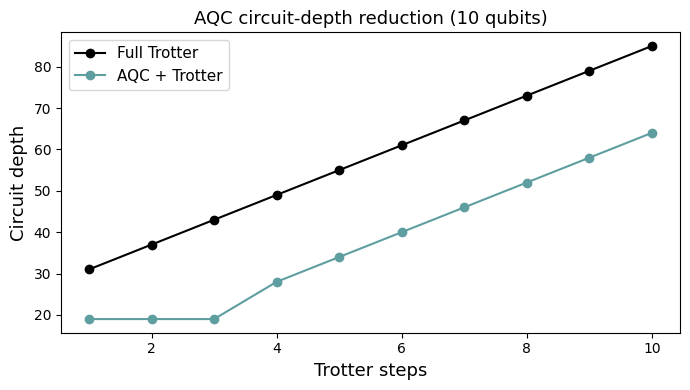

In [3]:
aqc_steps_small = 3

# ── Step 2a: Target circuits (first aqc_steps circuits from Step 1) ──
target_circuits_small = {
    k: circuits_small[k - 1] for k in range(1, aqc_steps_small + 1)
}
print("Step 2a — target circuit depths:")
for k, qc in target_circuits_small.items():
    print(f"  k={k}: depth = {qc.depth()}")

# ── Step 2b: Compute target MPS ──
aqc_sim_small = QuimbSimulator(
    quimb_circuit_factory=partial(
        qtn.CircuitMPS, gate_opts=dict(cutoff=1e-8, max_bond=32)
    ),
    autodiff_backend="jax",
)
print("\nStep 2b — target MPS:")
target_mps_small = {}
for k in range(1, aqc_steps_small + 1):
    target_mps_small[k] = tensornetwork_from_circuit(
        target_circuits_small[k], aqc_sim_small
    )
    print(f"  k={k}: max bond = {target_mps_small[k].psi.max_bond()}")

# ── Step 2c: Generate ansatz and optimize parameters ──
ansatz_small, initial_params_small = generate_ansatz_from_circuit(
    target_circuits_small[1], qubits_initially_zero=True
)
initial_params_small = np.array(initial_params_small)
print(
    f"\nStep 2c — ansatz: {ansatz_small.num_parameters} parameters, depth = {ansatz_small.depth()}"
)

aqc_circuits_small = {}
aqc_params_small = {}
for k in range(1, aqc_steps_small + 1):
    x0 = aqc_params_small.get(k - 1, initial_params_small)
    obj = MaximizeStateFidelity(
        target_mps_small[k], ansatz_small, aqc_sim_small
    )
    t0 = timeit.default_timer()
    result = scipy.optimize.minimize(
        obj.loss_function,
        x0,
        method="L-BFGS-B",
        jac=True,
        options=dict(maxiter=300),
    )
    elapsed = timeit.default_timer() - t0
    aqc_params_small[k] = result.x
    aqc_circuits_small[k] = ansatz_small.assign_parameters(result.x)
    print(
        f"  k={k}: fidelity = {1 - result.fun:.4f}, depth = {aqc_circuits_small[k].depth()}, {elapsed:.1f}s"
    )

# ── Step 2d: Assemble full circuit set (AQC + Trotter) ──
all_circuits_small = []
for k in range(1, aqc_steps_small + 1):
    all_circuits_small.append(aqc_circuits_small[k])
for k in range(1, time_steps_small - aqc_steps_small + 1):
    all_circuits_small.append(
        mixed_circuit(
            n_small, aqc_circuits_small[aqc_steps_small], k, half_t, full_t
        )
    )

full_depths = [
    circuits_small[k - 1].depth() for k in range(1, time_steps_small + 1)
]
aqc_depths = [qc.depth() for qc in all_circuits_small]
print(f"\nStep 2d — assembled {len(all_circuits_small)} circuits")
print(
    f"  Depth at step {time_steps_small}: Trotter = {full_depths[-1]}, AQC+Trotter = {aqc_depths[-1]}"
)

steps_axis = np.arange(1, time_steps_small + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps_axis, full_depths, "-o", color="black", label="Full Trotter")
ax.plot(
    steps_axis, aqc_depths, "-o", color="cadetblue", label="AQC + Trotter"
)
ax.set_xlabel("Trotter steps", fontsize=13)
ax.set_ylabel("Circuit depth", fontsize=13)
ax.set_title(f"AQC circuit-depth reduction ({n_small} qubits)", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Step 3: Execute using Qiskit primitives

We simulate each AQC-compiled circuit using the `StatevectorEstimator` primitive and extract the expectation value $\langle\sigma_i^z\rangle$ for every qubit $i$ at each time step $t$. These values form the retarded Green's function matrix $G^R(j, j_c, t)$.

In [4]:
estimator = StatevectorEstimator()
rgf_mat = np.zeros((time_steps_small, n_small))

for t_idx, qc in enumerate(all_circuits_small):
    pub = (qc, observables_small)
    job = estimator.run([pub])
    result = job.result()
    rgf_mat[t_idx, :] = result[0].data.evs

    if (t_idx + 1) % 5 == 0:
        print(f"  Completed time step {t_idx + 1}/{time_steps_small}")

print(f"RGF matrix shape: {rgf_mat.shape}")

  Completed time step 5/10
  Completed time step 10/10
RGF matrix shape: (10, 10)


### Step 4: Post-process and return result in desired classical format

We now Fourier-transform the RGF into the dynamical structure factor $S(q, \omega)$, apply mirror symmetry, clip negative values, and plot both the RGF and the DSF.

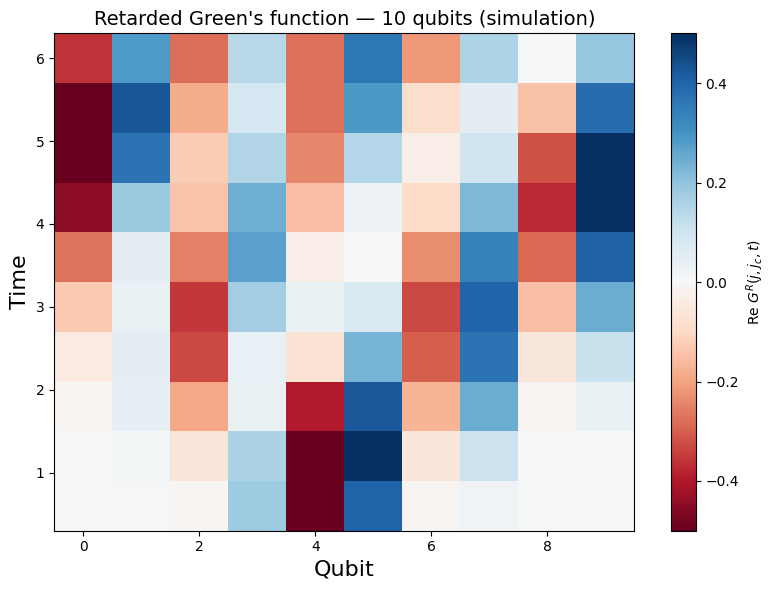

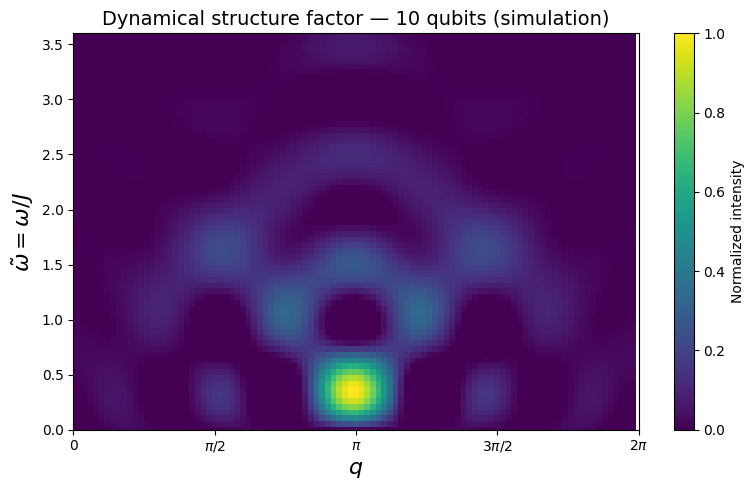

In [5]:
# -- Compute DSF --
q_res, w_res = 100, 100
spectrum_small = get_dsf(n_small, rgf_mat, dt, time_steps_small, q_res, w_res)
spectrum_small = -(spectrum_small + spectrum_small[:, ::-1]) / 2
spectrum_small = np.clip(spectrum_small, a_min=0, a_max=None)

# -- Plot retarded Green's function --
plot_rgf(
    n_small,
    rgf_mat,
    time_steps_small,
    dt,
    title=f"Retarded Green's function — {n_small} qubits (simulation)",
)

# -- Plot DSF --
plot_dsf(
    spectrum_small,
    dt,
    q_res,
    w_res,
    title=f"Dynamical structure factor — {n_small} qubits (simulation)",
)

## Large-scale hardware execution

We now scale up to **20 qubits**. Note that the paper scaled to 50 qubits, but reaching that scale required a large amount of computational resources to run AQC.

The code below follows the same four-step structure as the small-scale example. The HVA ground-state parameters are again optimized via MPS simulation, this time with a smaller bond-dimension budget that matches the AQC settings. The following table summarizes how the large-scale experiment differs from the small-scale one:

| | Small scale | Large scale |
|---|---|---|
| Qubits | 10 | 20 |
| Time steps | 10 | 20 |
| AQC checkpoints | 3 | 5 |
| HVA layers | 3 | 6 |
| Reference ground-state energy | Exact diagonalization | DMRG |
| MPS max bond dimension | 32 | 10 |
| Estimator | `StatevectorEstimator` | QPU with DD + Pauli twirling + TREX |

In [ ]:
import timeit

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_addon_aqc_tensor import generate_ansatz_from_circuit
from qiskit_addon_aqc_tensor.objective import MaximizeStateFidelity
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import QiskitRuntimeService

# ── Parameters ──────────────────────────────────────────────────────────────
n_large = 20  # 10 → 20
J = 1.0
Jz = 1.0
dt = 0.6
time_steps_large = 20  # 10 → 20
center_large = n_large // 2 - 1
aqc_steps_large = 5  # 3 → 5
gs_layers_large = 6  # 3 → 6

# ── Step 1: Map ──────────────────────────────────────────────────────────────
# Ground-state energy via DMRG (substitute for exact diagonalization)
builder = qtn.SpinHam1D(S=1 / 2)
builder += J * 0.5, "+", "-"
builder += J * 0.5, "-", "+"
builder += Jz, "Z", "Z"
H_mpo = builder.build_mpo(L=n_large)
dmrg = qtn.DMRG2(H_mpo, cutoffs=1e-10)
dmrg.solve(tol=1e-10, verbosity=0)
print(f"Ground-state energy (DMRG): {dmrg.energy:.6f}")

# Optimize HVA parameters by minimizing <H> via MPS simulation. Truncation
# (max_bond=10, cutoff=1e-4) matches the AQC settings used below.
# Same near-identity / near-SWAP init as the small-scale case.
rng = np.random.default_rng(12345)
x0_large = np.tile([0.0, np.pi / 2], gs_layers_large) + rng.normal(
    scale=0.1, size=2 * gs_layers_large
)
print("Optimizing ground state ansatz...")
t0 = timeit.default_timer()
gs_params_large, hva_energy_large = optimize_gs_params(
    n_large,
    gs_layers_large,
    x0_large,
    J=J,
    Jz=Jz,
    max_bond=10,
    cutoff=1e-4,
)
t1 = timeit.default_timer()
print(f"Finished optimizing ground state ansatz in {t1 - t0} seconds.")
print(f"Ground state ansatz energy: {hva_energy_large:.6f}")

gs_circuit_large = build_gs_ansatz(
    n_large, gs_params_large, gs_layers_large
).decompose(["PauliEvolution"])

H_pair = SparsePauliOp(
    ["XX", "YY", "ZZ"], coeffs=[0.25 * J, 0.25 * J, 0.25 * J]
)
half_t_lg = QuantumCircuit(2)
half_t_lg.append(PauliEvolutionGate(H_pair, time=dt / 2), [0, 1])
half_t_lg = half_t_lg.decompose()
full_t_lg = QuantumCircuit(2)
full_t_lg.append(PauliEvolutionGate(H_pair, time=dt), [0, 1])
full_t_lg = full_t_lg.decompose()

circuits_large = [
    trotter_circuit(
        n_large, gs_circuit_large, t, half_t_lg, full_t_lg, center_large
    )
    for t in range(1, time_steps_large + 1)
]
print(
    f"Built {len(circuits_large)} circuits, deepest depth = {circuits_large[-1].depth()}"
)

observables_large = [
    SparsePauliOp("I" * (n_large - 1 - i) + "Z" + "I" * i)
    for i in range(n_large)
]

# ── Step 2: AQC ──────────────────────────────────────────────────────────────
target_circuits_large = {
    k: circuits_large[k - 1] for k in range(1, aqc_steps_large + 1)
}

aqc_sim_large = QuimbSimulator(
    quimb_circuit_factory=partial(
        qtn.CircuitMPS,
        gate_opts=dict(cutoff=1e-4, max_bond=10),  # truncated (32 → 10)
    ),
    autodiff_backend="jax",
)

target_mps_large = {}
for k in range(1, aqc_steps_large + 1):
    target_mps_large[k] = tensornetwork_from_circuit(
        target_circuits_large[k], aqc_sim_large
    )

ansatz_large, initial_params_large = generate_ansatz_from_circuit(
    target_circuits_large[1], qubits_initially_zero=True
)
initial_params_large = np.array(initial_params_large)
print(
    f"Ansatz: {ansatz_large.num_parameters} parameters, depth = {ansatz_large.depth()}"
)

aqc_circuits_large = {}
aqc_params_large = {}
for k in range(1, aqc_steps_large + 1):
    x0 = aqc_params_large.get(k - 1, initial_params_large)
    obj = MaximizeStateFidelity(
        target_mps_large[k], ansatz_large, aqc_sim_large
    )
    t0 = timeit.default_timer()
    result = scipy.optimize.minimize(
        obj.loss_function,
        x0,
        method="L-BFGS-B",
        jac=True,
        options=dict(maxiter=10),
    )
    elapsed = timeit.default_timer() - t0
    aqc_params_large[k] = result.x
    aqc_circuits_large[k] = ansatz_large.assign_parameters(result.x)
    print(
        f"  k={k}: fidelity = {1 - result.fun:.4f}, depth = {aqc_circuits_large[k].depth()}, {elapsed:.1f}s"
    )

all_circuits_large = []
for k in range(1, aqc_steps_large + 1):
    all_circuits_large.append(aqc_circuits_large[k])
for k in range(1, time_steps_large - aqc_steps_large + 1):
    all_circuits_large.append(
        mixed_circuit(
            n_large,
            aqc_circuits_large[aqc_steps_large],
            k,
            half_t_lg,
            full_t_lg,
        )
    )

# ── Step 3: Execute on IBM Quantum hardware ───────────────────────────────────
# (replaces StatevectorEstimator)
service = QiskitRuntimeService()
backend = service.least_busy(
    min_num_qubits=n_large, operational=True, simulator=False
)
print(f"Backend: {backend.name}")

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_circuits = pm.run(all_circuits_large, num_processes=1)
isa_obs = [
    SparsePauliOp.from_list(
        [("I" * i + "Z" + "I" * (n_large - i - 1), 1)]
    ).apply_layout(isa_circuits[0].layout)
    for i in range(n_large)
]

estimator = Estimator(backend)
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XY4"
estimator.options.twirling.enable_gates = True
estimator.options.twirling.num_randomizations = 1000
estimator.options.twirling.shots_per_randomization = 128
estimator.options.resilience.measure_mitigation = True
estimator.options.resilience.measure_noise_learning.num_randomizations = 32
estimator.options.resilience.measure_noise_learning.shots_per_randomization = 100

mid = time_steps_large // 2
pubs = [(qc, isa_obs) for qc in isa_circuits]
job_1 = estimator.run(pubs[:mid])
job_2 = estimator.run(pubs[mid:])
print(f"Job 1: {job_1.job_id()}")
print(f"Job 2: {job_2.job_id()}")

result_1 = job_1.result()
result_2 = job_2.result()

rgf_mat = np.zeros((time_steps_large, n_large))
for i in range(mid):
    rgf_mat[i, :] = result_1[i].data.evs[::-1]
for i in range(time_steps_large - mid):
    rgf_mat[mid + i, :] = result_2[i].data.evs[::-1]

# ── Step 4: Post-process ──────────────────────────────────────────────────────
q_res, w_res = 100, 100
spectrum_large = get_dsf(n_large, rgf_mat, dt, time_steps_large, q_res, w_res)
spectrum_large = -(spectrum_large + spectrum_large[:, ::-1]) / 2
spectrum_large = np.clip(spectrum_large, a_min=0, a_max=None)

plot_rgf(
    n_large,
    rgf_mat,
    time_steps_large,
    dt,
    title=f"Retarded Green's function — {n_large} qubits (QPU)",
)
plot_dsf(
    spectrum_large,
    dt,
    q_res,
    w_res,
    title=rf"KCuF$_3$ DSF — {n_large} qubits (QPU)"
    "\n(AQC + DD + Pauli twirling + TREX)",
)

Ground-state energy (DMRG): -8.682473
Optimizing ground state ansatz...


## Next steps
If you found this work interesting, you might be interested in the following material:
<Admonition type="tip" title="Recommendations">

- [Lee et al., "Benchmarking quantum simulation with neutron-scattering experiments" (arXiv:2603.15608)](https://arxiv.org/abs/2603.15608) — the reference paper this tutorial is based on
- [Error Suppression and Mitigation with Qiskit Runtime](https://docs.quantum.ibm.com/guides/error-mitigation-and-suppression-techniques) — DD, Pauli twirling, and TREX used in the hardware experiments
- [Approximate quantum compilation for time evolution circuits](https://quantum.cloud.ibm.com/docs/en/tutorials/approximate-quantum-compilation-for-time-evolution) — tutorial on AQC-Tensor
- [AQC-Tensor documentation](https://qiskit.github.io/qiskit-addon-aqc-tensor/)

</Admonition>